# COVID One-Year Forecast Evaluation

This notebook adds an intermediate fixed-split forecast evaluation: the model is trained through the first year of COVID and then asked to forecast the subsequent COVID/recovery period.

This is not a full reconstruction of the forecasting comparison. It is a focused robustness check for the main SSM family, especially `baseline_m4` and `fixed_slope_m4`.

## 1. Design

The split is:

| split | train | test | purpose |
|---|---|---|---|
| `covid_one_year` | 2002-04-01 to 2021-02-01 | 2021-03-01 to 2023-05-01 | Include roughly the first COVID year in training, then forecast the later COVID/recovery period through the `baseline_m4` covid_main endpoint. |

Models included in this first implementation:

- `seasonal_naive`: unconditional benchmark using prior-year monthly values.
- `ssm_conditional_baseline_m4`: existing local linear trend + seasonal + baseline_m4 event dummies.
- `ssm_fixed_slope`: fixed-slope SSM with the same event dummies; slope disturbance is removed from the selection matrix, so slope noise is fixed at zero.

SARIMAX, Prophet, and Autoformer are intentionally excluded in this first pass. Conditional forecasts use known test-period event dummies.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loader import load_connected_parcel_data
from src.forecasting.evaluation import evaluate_forecasts
from src.forecasting.forecast_utils import make_forecast_frame
from src.forecasting.naive import seasonal_naive_forecast
from src.forecasting.ssm import fit_ssm, forecast_ssm, prepare_ssm_exog_from_spec, select_nonconstant_exog

DATA_PATH = ROOT / "data" / "processed" / "parcel_volume_connected.csv"
PREDICTIONS_DIR = ROOT / "output" / "forecasts" / "predictions"
METRICS_DIR = ROOT / "output" / "forecasts" / "metrics"
FIGURES_DIR = ROOT / "output" / "forecasts" / "figures"
for path in [PREDICTIONS_DIR, METRICS_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FORECAST_PATH = PREDICTIONS_DIR / "covid_one_year_forecasts.csv"
METRICS_PATH = METRICS_DIR / "covid_one_year_forecast_metrics.csv"
PERIOD_METRICS_PATH = METRICS_DIR / "covid_one_year_forecast_metrics_by_period.csv"
FIT_SUMMARY_PATH = METRICS_DIR / "covid_one_year_fit_summary.csv"
FIGURE_PATH = FIGURES_DIR / "covid_one_year_forecast_comparison.png"

SPLIT_NAME = "covid_one_year"
TRAIN_START = "2002-04-01"
TRAIN_END = "2021-02-01"
TEST_START = "2021-03-01"
TEST_END = "2023-05-01"


## 2. Load Data And Create Split

The connected parcel volume series is used. Evaluation is on `number_parcels`; SSM estimation uses the log target `y`.

In [2]:
def make_covid_one_year_split(df: pd.DataFrame) -> dict:
    data = df.copy()
    data.index = pd.to_datetime(data.index).to_period("M").to_timestamp()
    data = data.sort_index()

    train_start = pd.Timestamp(TRAIN_START)
    train_end = pd.Timestamp(TRAIN_END)
    test_start = pd.Timestamp(TEST_START)
    test_end = pd.Timestamp(TEST_END)

    expected = pd.date_range(train_start, test_end, freq="MS")
    missing = expected.difference(data.index)
    if len(missing) > 0:
        raise ValueError(f"Requested covid_one_year period has missing months: {missing}")

    return {
        "split": SPLIT_NAME,
        "train_start": train_start,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
        "train": data.loc[train_start:train_end].copy(),
        "test": data.loc[test_start:test_end].copy(),
    }


df = load_connected_parcel_data(DATA_PATH)
split = make_covid_one_year_split(df)
train = split["train"]
test = split["test"]

split_summary = pd.DataFrame([
    {
        "split": SPLIT_NAME,
        "train_start": train.index.min().strftime("%Y-%m-%d"),
        "train_end": train.index.max().strftime("%Y-%m-%d"),
        "train_n": len(train),
        "test_start": test.index.min().strftime("%Y-%m-%d"),
        "test_end": test.index.max().strftime("%Y-%m-%d"),
        "test_n": len(test),
    }
])
split_summary


,split,train_start,train_end,train_n,test_start,test_end,test_n
0,covid_one_year,2002-04-01,2021-02-01,227,2021-03-01,2023-05-01,27


## 3. baseline_m4 Exogenous Dummies

The conditional SSM forecasts use the `baseline_m4` event dummies known in the test period.

Important: `post_stat_change` starts in 2022-08, while this split trains only through 2021-02. Therefore `post_stat_change` is constant at 0 in the training period and is excluded by the existing nonconstant-exog rule. This means the model cannot estimate a post-statistical-connection level shift from this training window. If forecast errors increase after 2022-08, this is a key interpretation point rather than a bug.

In [3]:
exog_all = prepare_ssm_exog_from_spec(df, "baseline_m4")
all_exog_columns = list(exog_all.columns)
raw_exog_train = exog_all.reindex(train.index)
raw_exog_test = exog_all.reindex(test.index)
exog_train, exog_test, used_exog_columns = select_nonconstant_exog(raw_exog_train, raw_exog_test)
excluded_exog_columns = [col for col in all_exog_columns if col not in used_exog_columns]

exog_summary_rows = []
for col in all_exog_columns:
    train_values = raw_exog_train[col].dropna()
    test_values = raw_exog_test[col].dropna()
    train_unique = sorted(train_values.unique().tolist())
    test_unique = sorted(test_values.unique().tolist())
    reason = "used"
    if col in excluded_exog_columns:
        if len(train_unique) == 1:
            reason = f"excluded: constant in train ({train_unique[0]})"
        else:
            reason = "excluded: no training variation"
    exog_summary_rows.append(
        {
            "exog": col,
            "train_active_months": int(train_values.sum()),
            "test_active_months": int(test_values.sum()),
            "train_unique_values": str(train_unique),
            "test_unique_values": str(test_unique),
            "decision": reason,
        }
    )

exog_summary = pd.DataFrame(exog_summary_rows)
exog_summary


,exog,train_active_months,test_active_months,train_unique_values,test_unique_values,decision
0,hike_dummy,27,0,"[0.0, 1.0]",[0.0],used
1,covid_main,12,27,"[0.0, 1.0]",[1.0],used
2,covid_wave1,2,0,"[0.0, 1.0]",[0.0],used
3,covid_2021,2,7,"[0.0, 1.0]","[0.0, 1.0]",used
4,post_stat_change,0,10,[0.0],"[0.0, 1.0]",excluded: constant in train (0.0)


## 4. Seasonal Naive Benchmark

`seasonal_naive` is an unconditional benchmark. It uses the value from 12 months earlier. For horizons beyond 12 months, the source month may fall inside the test period; the existing implementation recursively uses the forecast generated for that source month, not the observed test value. The check below records whether each source month came from training data or from a previously generated forecast.

In [4]:
seasonal_forecast = seasonal_naive_forecast(
    train,
    test,
    target_col="number_parcels",
    model="seasonal_naive",
    split=SPLIT_NAME,
    forecast_type="unconditional",
    spec_name="seasonal_naive",
    target_scale="original",
)
seasonal_forecast["information_set"] = "unconditional"

seasonal_source_rows = []
forecast_dates = set(pd.to_datetime(seasonal_forecast["date"]).dt.to_period("M").dt.to_timestamp())
train_dates = set(train.index)
for date in test.index:
    source_date = (date - pd.DateOffset(months=12)).to_period("M").to_timestamp()
    if source_date in train_dates:
        source_type = "train_actual"
    elif source_date in forecast_dates:
        source_type = "previous_generated_forecast"
    else:
        source_type = "missing"
    seasonal_source_rows.append({"date": date, "source_date": source_date, "source_type": source_type})

seasonal_source_check = pd.DataFrame(seasonal_source_rows)
seasonal_source_check["source_type"].value_counts().rename_axis("source_type").reset_index(name="months")


,source_type,months
0,previous_generated_forecast,15
1,train_actual,12


## 5. baseline_m4 SSM Conditional Forecast

This is the existing main-analysis SSM structure: local linear trend, seasonal component, and `baseline_m4` event dummies. It is refit on the `covid_one_year` training window and forecast conditionally using known test-period dummies.

In [5]:
def fit_status_row(result, model: str, spec_name: str, status: str, error: str, warnings_list: list[str]) -> dict:
    retvals = (getattr(result, "mle_retvals", {}) or {}) if result is not None else {}
    return {
        "split": SPLIT_NAME,
        "model": model,
        "forecast_type": "conditional" if model != "seasonal_naive" else "unconditional",
        "information_set": "conditional_exog_known" if model != "seasonal_naive" else "unconditional",
        "spec_name": spec_name,
        "train_start": TRAIN_START,
        "train_end": TRAIN_END,
        "test_start": TEST_START,
        "test_end": TEST_END,
        "used_exog_columns": ",".join(used_exog_columns) if model != "seasonal_naive" else "",
        "excluded_exog_columns": ",".join(excluded_exog_columns) if model != "seasonal_naive" else "",
        "converged": retvals.get("converged", np.nan),
        "warnflag": retvals.get("warnflag", np.nan),
        "log_likelihood": float(result.llf) if result is not None else np.nan,
        "aic": float(result.aic) if result is not None else np.nan,
        "bic": float(result.bic) if result is not None else np.nan,
        "status": status,
        "error": error,
        "warning_messages": " | ".join(warnings_list),
    }


fit_summary_rows = []

try:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        baseline_result = fit_ssm(train, exog_train, target_col="y")
    baseline_warnings = [str(w.message) for w in caught]
    baseline_forecast = forecast_ssm(
        baseline_result,
        test,
        exog_test,
        split=SPLIT_NAME,
        spec_name="baseline_m4",
    )
    baseline_forecast["model"] = "ssm_conditional_baseline_m4"
    baseline_forecast["information_set"] = "conditional_exog_known"
    fit_summary_rows.append(fit_status_row(baseline_result, "ssm_conditional_baseline_m4", "baseline_m4", "success", "", baseline_warnings))
except Exception as exc:
    baseline_result = None
    baseline_forecast = pd.DataFrame()
    fit_summary_rows.append(fit_status_row(None, "ssm_conditional_baseline_m4", "baseline_m4", "failed", str(exc), []))
    raise

baseline_forecast.head()


,date,cutoff,horizon,y_true,y_pred,model,split,forecast_type,spec_name,target_col,target_scale,information_set
0,2021-03-01,2021-02-01,1,415780.0,385963.290769,ssm_conditional_baseline_m4,covid_one_year,conditional,baseline_m4,number_parcels,original,conditional_exog_known
1,2021-04-01,2021-02-01,2,387367.0,378530.362546,ssm_conditional_baseline_m4,covid_one_year,conditional,baseline_m4,number_parcels,original,conditional_exog_known
2,2021-05-01,2021-02-01,3,375965.0,377530.086529,ssm_conditional_baseline_m4,covid_one_year,conditional,baseline_m4,number_parcels,original,conditional_exog_known
3,2021-06-01,2021-02-01,4,410758.0,399864.607324,ssm_conditional_baseline_m4,covid_one_year,conditional,baseline_m4,number_parcels,original,conditional_exog_known
4,2021-07-01,2021-02-01,5,426318.0,446080.383558,ssm_conditional_baseline_m4,covid_one_year,conditional,baseline_m4,number_parcels,original,conditional_exog_known


## 6. fixed_slope_m4 SSM Conditional Forecast

The fixed-slope SSM uses the same exogenous variables as `baseline_m4`, after dropping variables that are constant in the training window. The slope state is retained, but slope disturbance is removed from the selection matrix; this fixes slope noise at zero.

In [6]:
class LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(sm.tsa.statespace.MLEModel):
    # Local linear trend + seasonal + exog, with slope disturbance fixed at zero.

    def __init__(self, endog, exog_list, param_names, seasonal_period=12, **kwargs):
        self.k_seasonal = seasonal_period
        k_states = 2 + (self.k_seasonal - 1)
        k_posdef = 2
        self.param_names_custom = param_names
        self.num_exog = len(exog_list)

        super().__init__(endog=endog, k_states=k_states, k_posdef=k_posdef, initialization="diffuse", **kwargs)

        self.ssm["design"] = np.zeros((1, k_states))
        self.ssm["design", 0, 0] = 1
        self.ssm["design", 0, 2] = 1

        transition = np.zeros((k_states, k_states))
        transition[0, 0] = 1
        transition[0, 1] = 1
        transition[1, 1] = 1
        transition[2, 2:] = -1
        for i in range(3, k_states):
            transition[i, i - 1] = 1
        self.ssm["transition"] = transition

        selection = np.zeros((k_states, k_posdef))
        selection[0, 0] = 1
        selection[2, 1] = 1
        self.ssm["selection"] = selection

        self.exogs = [ex.values.reshape(1, -1) for ex in exog_list]
        self.ssm["obs_intercept"] = np.zeros((1, len(endog)))

    @property
    def param_names(self):
        return self.param_names_custom

    def transform_params(self, unconstrained):
        constrained = unconstrained.copy()
        constrained[:3] = constrained[:3] ** 2
        return constrained

    def untransform_params(self, constrained):
        unconstrained = constrained.copy()
        unconstrained[:3] = np.sqrt(unconstrained[:3])
        return unconstrained

    def update(self, params, **kwargs):
        params = super().update(params, **kwargs)
        self["obs_cov", 0, 0] = params[0]
        self["state_cov", 0, 0] = params[1]
        self["state_cov", 1, 1] = params[2]

        total_exog_effect = 0
        for i in range(self.num_exog):
            total_exog_effect += params[3 + i] * self.exogs[i]
        self["obs_intercept", 0, :] = total_exog_effect


COEFF_START_HINTS = {"covid_main": -2.0, "covid_wave1": -2.0, "covid_2021": -3.0}

def make_fixed_slope_param_names(exog_names: list[str]) -> list[str]:
    return ["obs_error", "level_noise", "seasonal_noise"] + [f"{name}_effect" for name in exog_names]

def build_fixed_slope_start_params(exog_names: list[str]) -> list[float]:
    init_variances = [0.01, 0.01, 0.001]
    init_coeffs = [COEFF_START_HINTS.get(name, 0.0) for name in exog_names]
    return init_variances + init_coeffs

def fit_fixed_slope_ssm(train_df: pd.DataFrame, exog_train_df: pd.DataFrame):
    exog = exog_train_df.reindex(train_df.index).astype(float)
    exog_names = list(exog.columns)
    param_names = make_fixed_slope_param_names(exog_names)
    model = LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(
        endog=train_df["y"].astype(float),
        exog_list=[exog[name] for name in exog_names],
        param_names=param_names,
        seasonal_period=12,
    )
    result = model.fit(start_params=build_fixed_slope_start_params(exog_names), maxiter=1000, disp=False)
    result.forecast_param_names = param_names
    result.forecast_exog_names = exog_names
    return result

def forecast_fixed_slope_ssm(result, train_df: pd.DataFrame, test_df: pd.DataFrame, exog_train_df: pd.DataFrame, exog_test_df: pd.DataFrame):
    exog_names = list(result.forecast_exog_names)
    train_endog = train_df["y"].astype(float)
    combined_endog = pd.concat([train_endog, pd.Series(np.nan, index=test_df.index, name="y")])
    combined_exog = pd.concat([
        exog_train_df.reindex(train_df.index).reindex(columns=exog_names).astype(float),
        exog_test_df.reindex(test_df.index).reindex(columns=exog_names).astype(float),
    ])
    forecast_model = LocalLinearTrendSeasonalFixedSlopeWithMultiFixedExog(
        endog=combined_endog.astype(float),
        exog_list=[combined_exog[name] for name in exog_names],
        param_names=list(result.forecast_param_names),
        seasonal_period=12,
    )
    forecast_result = forecast_model.smooth(result.params)
    y_pred_log = forecast_result.predict(start=len(train_df), end=len(combined_endog) - 1)
    y_pred = np.exp(np.asarray(y_pred_log, dtype=float))
    frame = make_forecast_frame(
        dates=test_df.index,
        y_true=test_df["number_parcels"].to_numpy(dtype=float),
        y_pred=y_pred,
        model="ssm_fixed_slope",
        split=SPLIT_NAME,
        forecast_type="conditional",
        spec_name="fixed_slope_m4",
        target_col="number_parcels",
        target_scale="original",
        cutoff=train_df.index[-1],
        horizons=list(range(1, len(test_df) + 1)),
    )
    frame["information_set"] = "conditional_exog_known"
    return frame


In [7]:
try:
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        fixed_slope_result = fit_fixed_slope_ssm(train, exog_train)
    fixed_slope_warnings = [str(w.message) for w in caught]
    fixed_slope_forecast = forecast_fixed_slope_ssm(
        fixed_slope_result,
        train,
        test,
        exog_train,
        exog_test,
    )
    fit_summary_rows.append(fit_status_row(fixed_slope_result, "ssm_fixed_slope", "fixed_slope_m4", "success", "", fixed_slope_warnings))
except Exception as exc:
    fixed_slope_result = None
    fixed_slope_forecast = pd.DataFrame()
    fit_summary_rows.append(fit_status_row(None, "ssm_fixed_slope", "fixed_slope_m4", "failed", str(exc), []))
    raise

fixed_slope_forecast.head()


,date,cutoff,horizon,y_true,y_pred,model,split,forecast_type,spec_name,target_col,target_scale,information_set
0,2021-03-01,2021-02-01,1,415780.0,385952.073764,ssm_fixed_slope,covid_one_year,conditional,fixed_slope_m4,number_parcels,original,conditional_exog_known
1,2021-04-01,2021-02-01,2,387367.0,378524.380811,ssm_fixed_slope,covid_one_year,conditional,fixed_slope_m4,number_parcels,original,conditional_exog_known
2,2021-05-01,2021-02-01,3,375965.0,377524.310755,ssm_fixed_slope,covid_one_year,conditional,fixed_slope_m4,number_parcels,original,conditional_exog_known
3,2021-06-01,2021-02-01,4,410758.0,399852.941120,ssm_fixed_slope,covid_one_year,conditional,fixed_slope_m4,number_parcels,original,conditional_exog_known
4,2021-07-01,2021-02-01,5,426318.0,446060.292324,ssm_fixed_slope,covid_one_year,conditional,fixed_slope_m4,number_parcels,original,conditional_exog_known


## 7. Combine Forecasts And Evaluate

All metrics are computed on the original `number_parcels` scale. MASE uses the same training period denominator for all models.

In [8]:
forecast_columns = [
    "date",
    "split",
    "model",
    "forecast_type",
    "information_set",
    "y_true",
    "y_pred",
    "horizon",
    "cutoff",
    "target_col",
    "target_scale",
    "spec_name",
]

all_forecasts = pd.concat([
    seasonal_forecast,
    baseline_forecast,
    fixed_slope_forecast,
], ignore_index=True)
all_forecasts = all_forecasts[forecast_columns]

metrics = evaluate_forecasts(
    all_forecasts,
    y_train=train["number_parcels"],
    group_cols=["split", "model", "forecast_type", "information_set", "spec_name"],
)
metrics = metrics.sort_values(["forecast_type", "rmse"]).reset_index(drop=True)
metrics


,split,model,forecast_type,information_set,spec_name,n,rmse,mae,mape,mase
0,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,27,18236.021545,14561.143942,3.670449,1.179661
1,covid_one_year,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,27,18244.596434,14565.324365,3.671551,1.180000
2,covid_one_year,seasonal_naive,unconditional,unconditional,seasonal_naive,27,19347.949050,14410.296296,3.614626,1.167440


## 8. Period-Specific Metrics

Period-specific metrics use the same training-period MASE denominator. The `post_stat_change_period` isolates 2022-08 to 2023-05, where the post-statistical-connection dummy is active in the test period but excluded from the fitted SSMs because it is constant in training.

In [9]:
periods = {
    "covid_after_first_year_2021": ("2021-03-01", "2021-12-01"),
    "covid_2022": ("2022-01-01", "2022-12-01"),
    "pre_reclassification_2023": ("2023-01-01", "2023-05-01"),
    "post_stat_change_period": ("2022-08-01", "2023-05-01"),
}

period_frames = []
for period_name, (start, end) in periods.items():
    period_df = all_forecasts[
        (pd.to_datetime(all_forecasts["date"]) >= pd.Timestamp(start))
        & (pd.to_datetime(all_forecasts["date"]) <= pd.Timestamp(end))
    ].copy()
    if period_df.empty:
        continue
    period_df["period"] = period_name
    period_frames.append(period_df)

period_forecasts = pd.concat(period_frames, ignore_index=True)
period_metrics = evaluate_forecasts(
    period_forecasts,
    y_train=train["number_parcels"],
    group_cols=["period", "split", "model", "forecast_type", "information_set", "spec_name"],
)
period_metrics = period_metrics.sort_values(["period", "forecast_type", "rmse"]).reset_index(drop=True)
period_metrics


,period,split,model,forecast_type,information_set,spec_name,n,rmse,mae,mape,mase
0,covid_2022,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,12,20198.946516,15534.025093,3.763062,1.258478
1,covid_2022,covid_one_year,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,12,20201.158334,15531.768514,3.762323,1.258296
2,covid_2022,covid_one_year,seasonal_naive,unconditional,unconditional,seasonal_naive,12,19902.538846,14161.333333,3.489374,1.147271
3,covid_after_first_year_2021,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,10,13483.335300,11083.846803,2.689878,0.897950
4,covid_after_first_year_2021,covid_one_year,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,10,13486.767833,11086.832176,2.690529,0.898192
5,covid_after_first_year_2021,covid_one_year,seasonal_naive,unconditional,unconditional,seasonal_naive,10,18922.712131,13545.200000,3.316195,1.097355
6,post_stat_change_period,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,10,22734.519864,19558.253067,5.086679,1.584498
7,post_stat_change_period,covid_one_year,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,10,22761.043884,19583.253015,5.093385,1.586524
8,post_stat_change_period,covid_one_year,seasonal_naive,unconditional,unconditional,seasonal_naive,10,15542.193761,13725.100000,3.593384,1.111930
9,pre_reclassification_2023,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,5,21283.535494,19180.823457,5.409321,1.553921


## 9. Plot Forecasts

The figure compares actual values and forecasts over the `covid_one_year` test period. A vertical line marks 2022-08, when `post_stat_change` begins.

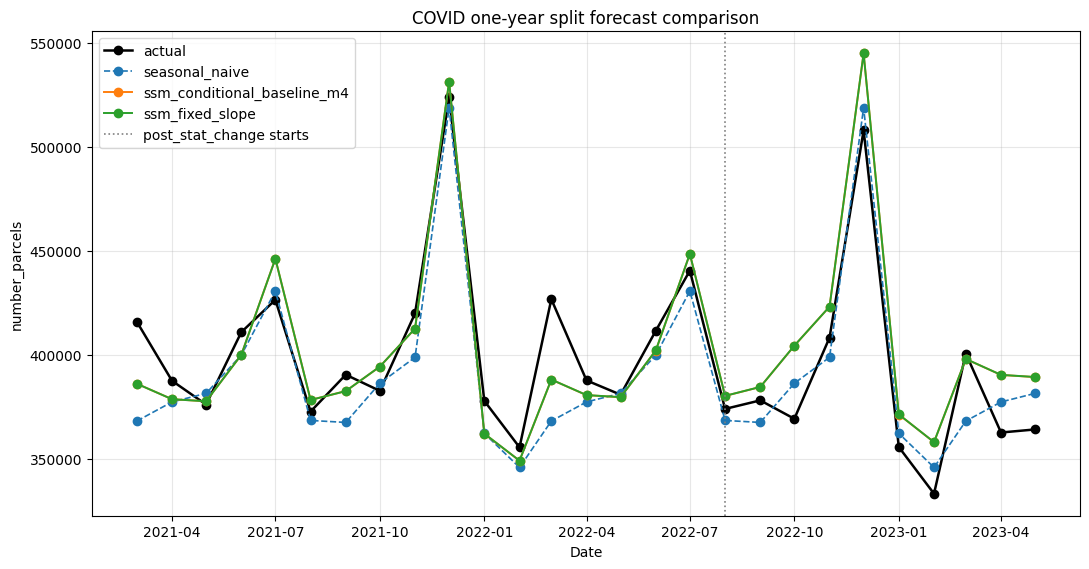

In [10]:
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(test.index, test["number_parcels"], marker="o", linewidth=1.8, color="black", label="actual")

plot_styles = {
    "seasonal_naive": {"linewidth": 1.2, "linestyle": "--"},
    "ssm_conditional_baseline_m4": {"linewidth": 1.4, "linestyle": "-"},
    "ssm_fixed_slope": {"linewidth": 1.4, "linestyle": "-"},
}
for model_name, group in all_forecasts.groupby("model"):
    style = plot_styles.get(model_name, {})
    ax.plot(pd.to_datetime(group["date"]), group["y_pred"], marker="o", label=model_name, **style)

ax.axvline(pd.Timestamp("2022-08-01"), color="gray", linestyle=":", linewidth=1.2, label="post_stat_change starts")
ax.set_title("COVID one-year split forecast comparison")
ax.set_xlabel("Date")
ax.set_ylabel("number_parcels")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()


## 10. Save Outputs

The outputs are new files specific to this intermediate split. Existing fixed A/fixed B prediction files and model comparison tables are not overwritten.

In [11]:
fit_summary = pd.DataFrame(fit_summary_rows)
fit_summary = pd.concat([
    pd.DataFrame([
        {
            "split": SPLIT_NAME,
            "model": "seasonal_naive",
            "forecast_type": "unconditional",
            "information_set": "unconditional",
            "spec_name": "seasonal_naive",
            "train_start": TRAIN_START,
            "train_end": TRAIN_END,
            "test_start": TEST_START,
            "test_end": TEST_END,
            "used_exog_columns": "",
            "excluded_exog_columns": "",
            "converged": np.nan,
            "warnflag": np.nan,
            "log_likelihood": np.nan,
            "aic": np.nan,
            "bic": np.nan,
            "status": "success",
            "error": "",
            "warning_messages": "seasonal naive uses recursive generated forecasts when prior-year source falls inside test",
        }
    ]),
    fit_summary,
], ignore_index=True)

all_forecasts.to_csv(FORECAST_PATH, index=False)
metrics.to_csv(METRICS_PATH, index=False)
period_metrics.to_csv(PERIOD_METRICS_PATH, index=False)
fit_summary.to_csv(FIT_SUMMARY_PATH, index=False)

for path in [FORECAST_PATH, METRICS_PATH, PERIOD_METRICS_PATH, FIT_SUMMARY_PATH, FIGURE_PATH]:
    print(f"saved {path}")

fit_summary


saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\predictions\covid_one_year_forecasts.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\metrics\covid_one_year_forecast_metrics.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\metrics\covid_one_year_forecast_metrics_by_period.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\metrics\covid_one_year_fit_summary.csv
saved C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\forecasts\figures\covid_one_year_forecast_comparison.png


,split,model,forecast_type,information_set,spec_name,train_start,train_end,test_start,test_end,used_exog_columns,excluded_exog_columns,converged,warnflag,log_likelihood,aic,bic,status,error,warning_messages
0,covid_one_year,seasonal_naive,unconditional,unconditional,seasonal_naive,2002-04-01,2021-02-01,2021-03-01,2023-05-01,,,NaN,NaN,NaN,NaN,NaN,success,,seasonal naive uses recursive generated foreca...
1,covid_one_year,ssm_conditional_baseline_m4,conditional,conditional_exog_known,baseline_m4,2002-04-01,2021-02-01,2021-03-01,2023-05-01,"hike_dummy,covid_main,covid_wave1,covid_2021",post_stat_change,1.0,0.0,448.369852,-854.739703,-782.815753,success,,
2,covid_one_year,ssm_fixed_slope,conditional,conditional_exog_known,fixed_slope_m4,2002-04-01,2021-02-01,2021-03-01,2023-05-01,"hike_dummy,covid_main,covid_wave1,covid_2021",post_stat_change,1.0,0.0,448.370444,-856.740887,-788.241887,success,,


## 11. Reading Notes

- This split includes the first COVID year in training and evaluates the later COVID/recovery period.
- `post_stat_change` is excluded from the fitted SSMs because it is constant at 0 through 2021-02. Forecast errors after 2022-08 should be interpreted with this limitation in mind.
- `seasonal_naive` is unconditional and does not use observed test-period values; for horizons beyond 12 months it recursively uses previously generated forecasts.
- The SSM forecasts are conditional: known test-period event dummies are supplied.
- This notebook does not update the global model comparison tables. It is an intermediate robustness check focused on the SSM family.